Nama Lengkap : Nazarul Bagus Riyadi

NIM : 240401010229

Kelas : IF404

---

# Praktikum Pertemuan 12: Asosiasi Data & Sistem Rekomendasi Dasar


## Import Library


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mlxtend'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

print('Library berhasil diimport')


Library berhasil diimport


## Langkah 1: Generate & Eksplorasi Dataset Transaksi

50 transaksi sintetis, tiap transaksi 2–5 item dari 10 produk. Pola disuntikkan: **Roti sering bersama Selai** pada 20 transaksi pertama.


Contoh transaksi: [['Keju', 'Roti', 'Mentega', 'Kopi', 'Selai'], ['Roti', 'Kopi', 'Teh', 'Selai', 'Mentega'], ['Kopi', 'Susu', 'Teh']]
Jumlah transaksi: 50

Frekuensi item:
Selai      26
Teh        23
Mentega    21
Telur      18
Keju       17
Roti       16
Kopi       16
Susu       16
Gula       16
Sereal      9
Name: count, dtype: int64


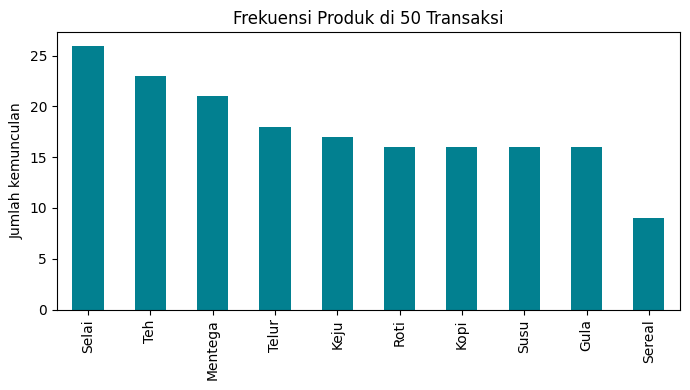

In [2]:
np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(np.random.choice(produk, n_item, replace=False).tolist())

for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

freq_item = pd.Series([item for t in transaksi for item in t]).value_counts()
print()
print('Frekuensi item:')
print(freq_item)

plt.figure(figsize=(7, 4))
freq_item.plot(kind='bar', color='#028090')
plt.title('Frekuensi Produk di 50 Transaksi')
plt.ylabel('Jumlah kemunculan')
plt.tight_layout()
plt.show()


## Langkah 2: One-Hot Encoding Transaksi

`TransactionEncoder` mengubah daftar item menjadi tabel boolean (satu kolom per produk).


In [3]:
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)
print(df.head())
print()
print('Shape encoded:', df.shape)


    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False

Shape encoded: (50, 10)


## Langkah 3: Frequent Itemset dengan Apriori

Beberapa nilai `min_support` dibanding. Support terlalu rendah → ratusan itemset berisik; terlalu tinggi → itemset habis.


In [4]:
for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print()
print('Top 10 frequent itemset (min_support=0.1):')
print(freq_items.head(10).to_string(index=False))


min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan

Top 10 frequent itemset (min_support=0.1):
 support     itemsets
    0.52      (Selai)
    0.46        (Teh)
    0.42    (Mentega)
    0.36      (Telur)
    0.34       (Keju)
    0.32       (Gula)
    0.32       (Kopi)
    0.32       (Roti)
    0.32       (Susu)
    0.24 (Selai, Teh)


## Langkah 4: Aturan Asosiasi

Saring `confidence >= 0.5` dan `lift > 1`, lalu urutkan berdasarkan Lift. Lift > 1 berarti antecedent dan consequent muncul bersama lebih sering daripada kebetulan.


In [5]:
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)

tampil = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
tampil['antecedents'] = tampil['antecedents'].apply(lambda x: ', '.join(sorted(x)))
tampil['consequents'] = tampil['consequents'].apply(lambda x: ', '.join(sorted(x)))
print(tampil.head(10).round(3).to_string(index=False))
print()
print('Jumlah aturan (confidence>=0.5, lift>1):', len(rules))


   antecedents consequents  support  confidence  lift
     Keju, Teh       Telur     0.12       0.857 2.381
Mentega, Selai        Kopi     0.10       0.625 1.953
    Gula, Roti       Selai     0.10       1.000 1.923
        Sereal     Mentega     0.14       0.778 1.852
    Teh, Telur        Keju     0.12       0.600 1.765
   Kopi, Selai     Mentega     0.10       0.714 1.701
   Keju, Telur         Teh     0.12       0.750 1.630
   Gula, Selai        Roti     0.10       0.500 1.562
 Kopi, Mentega       Selai     0.10       0.714 1.374
          Roti       Selai     0.22       0.688 1.322

Jumlah aturan (confidence>=0.5, lift>1): 16


### Interpretasi aturan

Aturan dengan Lift tertinggi adalah yang paling kuat secara statistik. Pola yang disuntikkan (**Roti → Selai**) diharapkan muncul dengan Lift > 1 — masuk akal secara bisnis: pembeli roti sering menambah selai.


## Langkah 5: Rekomender Content-Based

Katalog 10 produk + kategori. Kemiriman dihitung dengan cosine similarity atas one-hot kategori — rekomendasi dari **atribut produk**, bukan dari keranjang belanja.


In [6]:
katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy']
})

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

print(katalog.to_string(index=False))
print()
print('Mirip dengan Roti:', rekomendasi_serupa('Roti'))


 produk kategori
   Roti   Bakery
  Selai   Bakery
   Susu    Dairy
 Sereal   Bakery
  Telur    Dairy
   Keju    Dairy
   Kopi  Minuman
   Gula    Bumbu
    Teh  Minuman
Mentega    Dairy

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


## Langkah 6: Bandingkan Kedua Pendekatan

Untuk produk yang sama (**Roti**): association rules memakai pola transaksi, content-based memakai kategori.


In [7]:
produk_target = 'Roti'

rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)].copy()
rules_terkait['consequents'] = rules_terkait['consequents'].apply(
    lambda x: ', '.join(sorted(x))
)
print('Rekomendasi dari Association Rules (antecedent mengandung Roti):')
if rules_terkait.empty:
    print('(tidak ada aturan yang lolos saringan)')
else:
    print(rules_terkait[['consequents', 'support', 'confidence', 'lift']]
          .head().round(3).to_string(index=False))

print()
print('Rekomendasi dari Content-Based:', rekomendasi_serupa(produk_target))


Rekomendasi dari Association Rules (antecedent mengandung Roti):
consequents  support  confidence  lift
      Selai     0.10       1.000 1.923
      Selai     0.22       0.688 1.322

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


### Kapan memakai yang mana

- **Association rules**: cocok untuk bundle/promo ("orang yang beli Roti cenderung beli Selai") — butuh data transaksi.
- **Content-based**: cocok saat transaksi masih sedikit, atau untuk item baru yang belum pernah dibeli bersama apa pun (cold start).
- **Hybrid**: gabungkan keduanya — aturan asosiasi untuk pola keranjang, content-based untuk mengisi jika aturan kosong.


## Kesimpulan

### Apa yang Dipelajari
- Market Basket Analysis: Apriori mencari frequent itemset, lalu membentuk aturan (support, confidence, lift)
- Content-based filtering: cosine similarity atas fitur produk (kategori)
- Dua pendekatan rekomendasi menjawab pertanyaan yang berbeda: "sering dibeli bersama" vs "mirip secara atribut"

### Temuan Utama
- `min_support=0.1` → 44 itemset; 0.05 terlalu ramai (74), 0.2 terlalu ketat (13)
- Aturan **Roti → Selai**: support 0.22, confidence 0.688, lift 1.322 — pola yang disuntikkan terbaca
- Content-based untuk Roti: Selai, Sereal (kategori Bakery yang sama). Kedua pendekatan sepakat di item teratas

### Keterbatasan
- Hanya 50 transaksi sintetis; aturan rapuh terhadap seed dan saringan support/confidence
- Content-based hanya memakai satu fitur (kategori) — produk satu kategori jadi "sama semua"
- Collaborative filtering belum diimplementasikan (modul menyinggung konsepnya)
